# $\lambda$ and $\rho$ across start dates: DJF, 45 hindcasts

`granger_lin_lambda_m.ipynb` computes these metrics with the sample axis running over
*months inside one hindcast* ($T=120$, start date decadal1961). Here the sample axis runs
over *start dates*: $J=45$ DJF means, one per hindcast, 29 members from four CMIP5 decadal
models. Successive entries are separate forecasts rather than successive months, which is
the axis Eade et al. score.

The formulas are unchanged. With $s_{-n}$ the ensemble mean over the other $N-1$ members
and $g$ the observations,

$$\lambda_m = \frac1N\sum_n\sqrt{1-2^{-2I(f_n;\,s_{-n})}},\qquad
  \rho_m = \frac1N\sum_n\mathrm{corr}\big(f_n,\,s_{-n}\big)$$

$$\lambda_o = \frac1N\sum_n\sqrt{1-2^{-2I(f_n;\,g)}},\qquad
  \rho_o = \frac1N\sum_n\mathrm{corr}\big(f_n,\,g\big)$$

plus the ensemble-mean pair $\lambda_o^s,\rho_o^s$ from $I(s;g)$ and $\mathrm{corr}(s,g)$,
and the ratios $\lambda=\lambda_o/\lambda_m$, $\rho=\rho_o/\rho_m$ that stand in for RPC.
$\lambda$ is formed per member and *then* averaged, as there.

The one thing that cannot be carried over is the bias. $J=45$ is a third of $T=120$, and
the KSG permutation null at $J=45$ is around 0.06 bits, which is $\lambda\approx0.3$
conjured out of independent noise. Every $\lambda$ below is formed from $I$ minus that
null, and the null is re-estimated here rather than reused.

## The DJF cube

`scripts/build_djf_cube.py` reduces the 9.5 GB of raw monthly `psl` under
`.scratch/eade_replication/fetch` to one winter mean per (start date, member) on HadCM3's
N48 grid. A DJF season is labelled by the January it ends in, and the season taken is the
first complete winter of each hindcast: for start-date index $j$ every model's output
begins Jan($1961+j$), so DJF is Dec($1961+j$) with Jan and Feb of $1962+j$ -- lead months
12-14, the same calendar months for all four models. Observations are HadSLP2r over those
three months on the same grid. The cube also carries `cube25`/`obs25`, the four winters
inside lead years 2-5 averaged, which is the winter-only analogue of the published
lead-2-5 annual mean; switching to it is one line here.

Members incomplete at any start date, and start dates incomplete for the surviving
members, are dropped rather than zero-filled. At $J=45$ one filled entry is 2% of the
sample, and the whole analysis then runs on a rectangle with no NaNs anywhere.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

_z = np.load("../data/djf_cube.npz")          # scripts/build_djf_cube.py
lats, lons, members = _z["lat"], _z["lon"], _z["members"]

_ok_n = np.isfinite(_z["cube"]).all(axis=(0, 2, 3))
_ok_j = (np.isfinite(_z["cube"][:, _ok_n]).all(axis=(1, 2, 3))
         & np.isfinite(_z["obs"]).all(axis=(1, 2)))
F = _z["cube"][_ok_j][:, _ok_n].transpose(1, 0, 2, 3).astype(float)   # (N, J, lat, lon)
G = _z["obs"][_ok_j].astype(float)                                    # (J, lat, lon)
N, J = F.shape[:2]
WINTER = 1962 + _z["j"][_ok_j]                # DJF labelled by the January it ends in

W = np.cos(np.deg2rad(lats))[:, None] * np.ones(len(lons))    # N48 spans both poles


def gm(a):
    """Area-weighted global mean, NaNs skipped. Plain means over-weight the polar rows."""
    m = np.isfinite(a)
    return float((a[m] * W[m]).sum() / W[m].sum())


PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180           # grid is 0..356.25E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=12)
    return h


print("%d members x %d start dates, DJF %d..%d, grid %d x %d"
      % (N, J, WINTER[0], WINTER[-1], len(lats), len(lons)))
print("dropped %d members, %d start dates; gaps in the kept rectangle: %d"
      % ((~_ok_n).sum(), (~_ok_j).sum(),
         np.isnan(F).sum() + np.isnan(G).sum()))
print("start dates kept:", ", ".join("%d" % w for w in WINTER))

29 members x 45 start dates, DJF 1962..2007, grid 73 x 96
dropped 0 members, 0 start dates; gaps in the kept rectangle: 0
start dates kept: 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007


## Detrending

`R.load_data` detrends the monthly ensemble with a degree-1 fit, and a degree-1 fit
carries an intercept, so it removes the window mean along with the drift. The same is done
here along the start-date axis, per member and per grid cell, and to the observations:
`detrend` subtracts the least-squares line *and* the mean, so every series entering an
estimator has mean zero to machine precision.

It matters more here than it did there. Over DJF 1962-2007 both modelled and observed SLP
carry a forced trend, and a trend shared by two series is correlation that has nothing to
do with forecast skill: left in, it inflates $\rho_o$ and $\lambda_o$ together, and
inflates $\rho_m$ and $\lambda_m$ as well, because every member carries the same forced
component. The `as-is` column keeps the trend so the size of that inflation stays visible;
`detrended` is the column to read.

In [2]:
def detrend(a):
    """Remove the least-squares line along the start-date axis, per grid cell.

    Takes the mean with it, so every returned series has mean zero to machine precision.
    """
    t = np.arange(a.shape[0], dtype=float)
    t -= t.mean()
    flat = a.reshape(a.shape[0], -1)
    slope = (t[:, None] * flat).sum(axis=0) / (t ** 2).sum()
    return (flat - t[:, None] * slope - flat.mean(axis=0)).reshape(a.shape)


TREATMENTS = ["as-is", "detrended"]
FIELDS = {"as-is": (F, G),
          "detrended": (np.stack([detrend(F[n]) for n in range(N)]), detrend(G))}


def loo_mean(Fx, n):
    """s_-n, the ensemble mean over the other N-1 members. No NaNs left to guard."""
    return (Fx.sum(axis=0) - Fx[n]) / (Fx.shape[0] - 1)


def pair(n, treatment):
    """(f_n, s_-n), both (J, lat, lon)."""
    Fx, _ = FIELDS[treatment]
    return Fx[n], loo_mean(Fx, n)


def pair_obs(n, treatment):
    """(f_n, g), both (J, lat, lon)."""
    Fx, Gx = FIELDS[treatment]
    return Fx[n], Gx


_t = np.arange(J, dtype=float)
_t -= _t.mean()
print("%-11s %13s %13s %15s %15s"
      % ("treatment", "max|mean| f", "max|mean| g", "f trend Pa/dec", "g trend Pa/dec"))
for _tr in TREATMENTS:
    _Fx, _Gx = FIELDS[_tr]
    _sf = (_t[:, None] * _Fx.reshape(N, J, -1).transpose(1, 0, 2).reshape(J, -1)
           ).sum(axis=0) / (_t ** 2).sum()
    _sg = (_t[:, None] * _Gx.reshape(J, -1)).sum(axis=0) / (_t ** 2).sum()
    print("%-11s %13.2e %13.2e %15.2f %15.2f"
          % (_tr, np.abs(_Fx.mean(axis=1)).max(), np.abs(_Gx.mean(axis=0)).max(),
             10 * np.abs(_sf).max(), 10 * np.abs(_sg).max()))

treatment     max|mean| f   max|mean| g  f trend Pa/dec  g trend Pa/dec
as-is            1.04e+05      1.04e+05          269.15          186.32
detrended        7.11e-12      7.11e-12            0.00            0.00


## The permutation null at $J=45$

KSG has no analytic bias correction -- its digamma terms are the estimator, not a
correction layered on top -- so the floor has to be resampled.
`estimator.statistical_test(n_tests, method="permutation_test")` permutes the first
variable, leaves the other alone, and returns the null distribution of $I$ under
independence; its mean is the floor.

One constant per treatment is enough, and here that is not an approximation. `R.mi_bits`
rank-transforms both variables to uniform marginals before estimating, so a permuted pair
is a pair of independent rank vectors of length $J$ whatever grid cell, member or
treatment it came from: the null is a property of $(J, k)$ alone. The across-case scatter
below is therefore Monte-Carlo noise on 60 permutations, and the observation side has to
land on the same number as the model side -- if it did not, something other than the
estimator would be setting the floor.

The last column is the point of the exercise: $\sqrt{1-2^{-2\,\mathrm{null}}}$ is the
$\lambda$ two independent series earn at $J=45$ for nothing.

In [3]:
import infomeasure as im     # for the estimator objects, which carry statistical_test

K = 5                        # KSG neighbours, this project's default
NULL_POINTS = [(la, lo) for la in range(3, 73, 6) for lo in range(0, 96, 9)]
NULL_MEMBERS = [0, N // 3, 2 * N // 3, N - 1]
NULL_TESTS = 60


def lam(I):
    """sqrt(1 - 2^-2I), argument of the sqrt clamped at 0."""
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


def mi_null_bits(x, y, n_tests=NULL_TESTS):
    """Mean of the permutation null in bits, from infomeasure's statistical_test."""
    est = im.estimator(R.copula(x), R.copula(y), measure="mi", approach="ksg",
                       k=K, base=2, noise_level=0, minkowski_p=np.inf)
    return float(est.statistical_test(
        n_tests=n_tests, method="permutation_test").null_mean)


def nulls(pairfn, treatment, stride=1):
    """One null per (sampled point, sampled member)."""
    out = []
    for la, lo in NULL_POINTS[::stride]:
        for held in NULL_MEMBERS:
            x, y = pairfn(held, treatment)
            out.append(mi_null_bits(x[:, la, lo], y[:, la, lo]))
    return np.array(out)


NULL_BITS, _null_sd = {}, {}
for _tr in TREATMENTS:
    _s = nulls(pair, _tr)
    NULL_BITS[_tr], _null_sd[_tr] = float(_s.mean()), float(_s.std(ddof=1))

_obs_null = float(nulls(pair_obs, "detrended", stride=4).mean())
assert abs(_obs_null - NULL_BITS["detrended"]) < 0.005


def excess_mi(I, treatment):
    """I minus the unconditional permutation null, in bits."""
    return np.asarray(I, float) - NULL_BITS[treatment]


print("%d points x %d members, %d permutations each"
      % (len(NULL_POINTS), len(NULL_MEMBERS), NULL_TESTS))
print("%-12s %9s %13s %12s %12s"
      % ("treatment", "null", "across-case", "se of mean", "lam(null)"))
for _tr in TREATMENTS:
    _n = len(NULL_POINTS) * len(NULL_MEMBERS)
    print("%-12s %9.4f %13.4f %12.4f %12.4f"
          % (_tr, NULL_BITS[_tr], _null_sd[_tr], _null_sd[_tr] / np.sqrt(_n),
             lam(NULL_BITS[_tr])))
print("%-12s %9.4f   (against the observations instead of s_-n)"
      % ("detrended", _obs_null))

132 points x 4 members, 60 permutations each
treatment         null   across-case   se of mean    lam(null)
as-is           0.0497        0.0129       0.0006       0.2580
detrended       0.0491        0.0125       0.0005       0.2566
detrended       0.0486   (against the observations instead of s_-n)


## The four fields

One KSG call per member per grid cell per treatment for the model side and the same again
for the observation side: $4\times29\times73\times96$ estimates, a few minutes cold, so
they are cached. Pearson is vectorised over the grid and needs no cache.

$\lambda$ comes from the bias-corrected $I$ throughout, $\rho$ from the raw correlation --
Pearson at $J=45$ has its own $O(1/J)$ bias, which the ratio columns later inherit.

In [4]:
CACHE = "../data/djf_lambda_cache.npz"


def mi_grid(pairfn, treatment):
    """I in bits for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
    return out


def pearson_grid(pairfn, treatment):
    """corr for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        a = x - x.mean(axis=0, keepdims=True)
        b = y - y.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


if os.path.exists(CACHE):
    _c = np.load(CACHE)
    I_N = {t: _c["m_" + t] for t in TREATMENTS}
    I_O = {t: _c["o_" + t] for t in TREATMENTS}
else:
    I_N = {t: mi_grid(pair, t) for t in TREATMENTS}
    I_O = {t: mi_grid(pair_obs, t) for t in TREATMENTS}
    np.savez_compressed(CACHE, **{"m_" + t: I_N[t] for t in TREATMENTS},
                        **{"o_" + t: I_O[t] for t in TREATMENTS})

LAM_N = {t: lam(excess_mi(I_N[t], t)) for t in TREATMENTS}        # (N, lat, lon)
LAM_M = {t: LAM_N[t].mean(axis=0) for t in TREATMENTS}            # (lat, lon)
R_N = {t: pearson_grid(pair, t) for t in TREATMENTS}
RHO_M = {t: np.nanmean(R_N[t], axis=0) for t in TREATMENTS}

LAM_O_N = {t: lam(excess_mi(I_O[t], t)) for t in TREATMENTS}
LAM_O = {t: LAM_O_N[t].mean(axis=0) for t in TREATMENTS}
R_O_N = {t: pearson_grid(pair_obs, t) for t in TREATMENTS}
RHO_O = {t: np.nanmean(R_O_N[t], axis=0) for t in TREATMENTS}

print("%-12s %8s %8s %8s %8s %8s %8s %9s"
      % ("treatment", "lam_m", "rho_m", "lam_o", "rho_o", "corr_m", "corr_o", "I<0"))
for t in TREATMENTS:
    m = np.isfinite(LAM_M[t]) & np.isfinite(RHO_M[t])
    mo = np.isfinite(LAM_O[t]) & np.isfinite(RHO_O[t])
    print("%-12s %8.4f %+8.4f %8.4f %+8.4f %+8.3f %+8.3f %8.1f%%"
          % (t, gm(LAM_M[t]), gm(RHO_M[t]), gm(LAM_O[t]), gm(RHO_O[t]),
             np.corrcoef(LAM_M[t][m], RHO_M[t][m])[0, 1],
             np.corrcoef(LAM_O[t][mo], RHO_O[t][mo])[0, 1],
             100 * np.mean(excess_mi(I_N[t], t) < 0)))

treatment       lam_m    rho_m    lam_o    rho_o   corr_m   corr_o       I<0
as-is          0.2556  +0.2588   0.1533  +0.0788   +0.928   +0.565     35.4%
detrended      0.2226  +0.2060   0.1563  +0.0677   +0.882   +0.595     42.2%


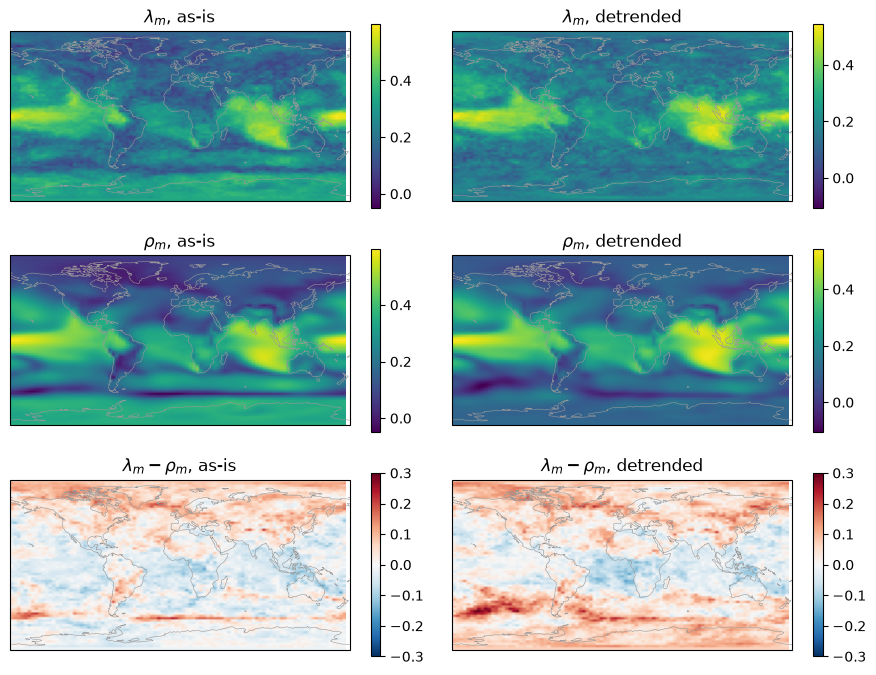

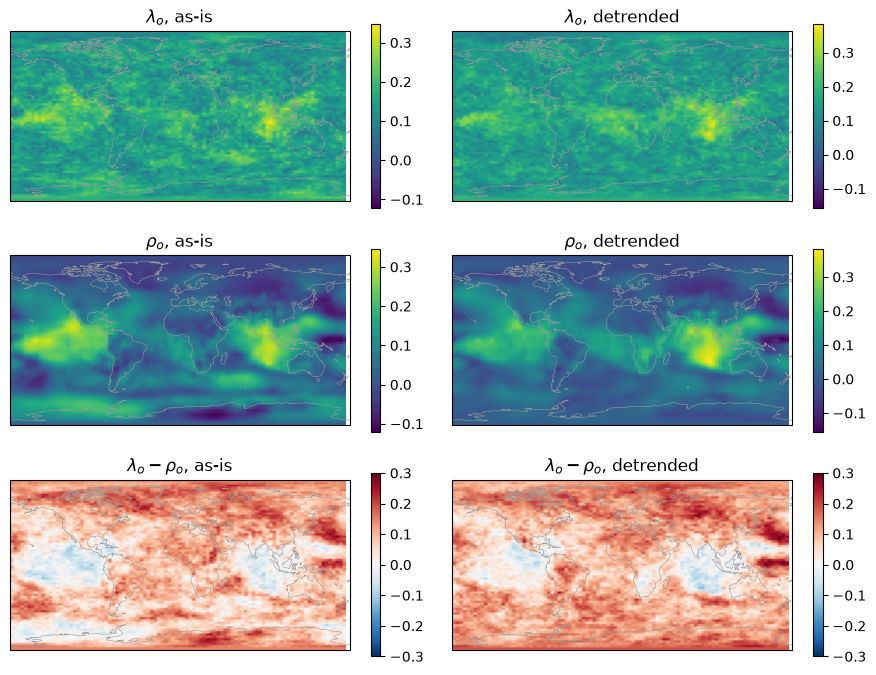

In [5]:
for name, A, B in (("m", LAM_M, RHO_M), ("o", LAM_O, RHO_O)):
    fig, axs = plt.subplots(3, 2, figsize=(9, 7), subplot_kw={"projection": PROJ})
    for i, t in enumerate(TREATMENTS):
        a, b = A[t], B[t]
        nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                        max(np.nanmax(a), np.nanmax(b)))
        h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_%s$, %s" % (name, t))
        h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_%s$, %s" % (name, t))
        h2 = panel(axs[2, i], a - b, "RdBu_r", Normalize(-0.3, 0.3),
                   "$\\lambda_%s - \\rho_%s$, %s" % (name, name, t))
        for ax, h in zip(axs[:, i], (h0, h1, h2)):
            fig.colorbar(h, ax=ax, shrink=0.85, label="")
    plt.tight_layout()
    plt.show()

## The ensemble-mean pair, and the ratios

$\lambda_o^s,\rho_o^s$ score the ensemble mean $s$ against the observations, one series
per grid cell rather than one per member. $\rho_o^s$ is the published anomaly correlation
before its clamp at zero, and `rho_m_var` is the published variance-based
$\rho_m=\sqrt{\mathrm{var}(s)/\overline{\mathrm{var}(f_n)}}$ -- neither touches an
estimator, so together they are the check that the preprocessing above is right.

The ratio columns are the RPC analogues: $\rho=\rho_o/\rho_m$ and $\lambda=\lambda_o/
\lambda_m$ from the per-member skill, $\rho^s,\lambda^s$ from the ensemble-mean skill.
Above one means the real world is more predictable than the model thinks it is.

In [6]:
RHO_O_S, LAM_O_S, RHO_M_VAR = {}, {}, {}
for t in TREATMENTS:
    Fx, Gx = FIELDS[t]
    x, y = Fx.mean(axis=0), Gx
    a = x - x.mean(axis=0, keepdims=True)
    b = y - y.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        RHO_O_S[t] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    LAM_O_S[t] = lam(excess_mi(
        np.array([[R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
                   for lo in range(x.shape[2])] for la in range(x.shape[1])]), t))
    RHO_M_VAR[t] = np.sqrt(x.var(axis=0) / Fx.var(axis=1).mean(axis=0))

RATIO = {t: {"rho": RHO_O[t] / RHO_M[t], "lam": LAM_O[t] / LAM_M[t],
             "rho^s": RHO_O_S[t] / RHO_M_VAR[t], "lam^s": LAM_O_S[t] / LAM_M[t]}
         for t in TREATMENTS}

print("%-12s %9s %9s %11s %11s | %7s %7s %7s %7s"
      % ("treatment", "lam_o^s", "rho_o^s", "rho_m var", "rho_m loo",
         "rho", "lam", "rho^s", "lam^s"))
for t in TREATMENTS:
    r = RATIO[t]
    print("%-12s %9.4f %+9.4f %11.4f %11.4f | %7.3f %7.3f %7.3f %7.3f"
          % (t, gm(LAM_O_S[t]), gm(RHO_O_S[t]), gm(RHO_M_VAR[t]), gm(RHO_M[t]),
             gm(r["rho"]), gm(r["lam"]), gm(r["rho^s"]), gm(r["lam^s"])))
print("\ncorr(rho_m loo, rho_m var) = %+.3f, corr(rho_o^s, rho_o) = %+.3f  [detrended]"
      % (np.corrcoef(RHO_M["detrended"].ravel(), RHO_M_VAR["detrended"].ravel())[0, 1],
         np.corrcoef(RHO_O_S["detrended"].ravel(), RHO_O["detrended"].ravel())[0, 1]))
print("cells with rho^s > 1: %.1f%%, with lam^s > 1: %.1f%%  [detrended]"
      % (100 * np.mean(RATIO["detrended"]["rho^s"] > 1),
         100 * np.mean(RATIO["detrended"]["lam^s"] > 1)))

treatment      lam_o^s   rho_o^s   rho_m var   rho_m loo |     rho     lam   rho^s   lam^s
as-is           0.1974   +0.1892      0.3575      0.2588 |   0.217   0.687   0.491   0.843
detrended       0.2084   +0.1743      0.3188      0.2060 |   0.229   0.802   0.483   1.013

corr(rho_m loo, rho_m var) = +0.995, corr(rho_o^s, rho_o) = +0.948  [detrended]
cells with rho^s > 1: 13.6%, with lam^s > 1: 41.5%  [detrended]


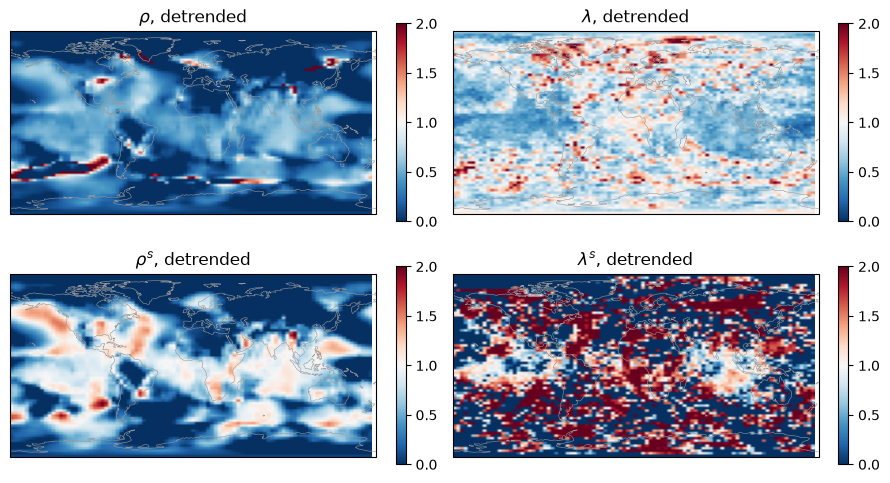

In [7]:
t = "detrended"
fig, axs = plt.subplots(2, 2, figsize=(9, 5), subplot_kw={"projection": PROJ})
nrm = Normalize(0.0, 2.0)
LABEL = {"rho": "$\\rho$", "lam": "$\\lambda$",
         "rho^s": "$\\rho^s$", "lam^s": "$\\lambda^s$"}
for ax, key in zip(axs.ravel(), ("rho", "lam", "rho^s", "lam^s")):
    h = panel(ax, RATIO[t][key], "RdBu_r", nrm, "%s, %s" % (LABEL[key], t))
    fig.colorbar(h, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

## $\lambda$ against $\rho$, and the spread across members

At $T=120$ the two metrics tracked each other closely once the null was removed. The
question here is whether $J=45$ leaves enough sample for that to survive: the scatter is
the same plot as there, and the right panel is the across-member spread of $\lambda_n$,
which at 45 points is dominated by estimator noise rather than by real differences between
members.

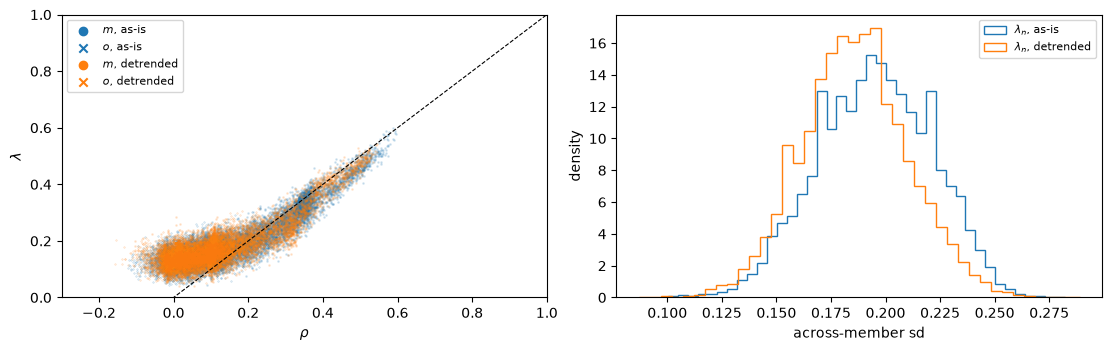

treatment      lam_n sd     r_n sd lam_o_n sd   r_o_n sd
as-is             0.195      0.152      0.172      0.145
detrended         0.186      0.154      0.172      0.150


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_M[t].ravel(), LAM_M[t].ravel(), s=1, alpha=0.15, color=c,
                   label="$m$, %s" % t)
    axs[0].scatter(RHO_O[t].ravel(), LAM_O[t].ravel(), s=1, alpha=0.15,
                   color=c, marker="x", label="$o$, %s" % t)
axs[0].plot([-0.3, 1], [-0.3, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho$")
axs[0].set_ylabel("$\\lambda$")
axs[0].set_xlim(-0.3, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_N[t].std(axis=0).ravel(), bins=40, histtype="step", density=True,
                color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-12s %10s %10s %10s %10s"
      % ("treatment", "lam_n sd", "r_n sd", "lam_o_n sd", "r_o_n sd"))
for t in TREATMENTS:
    print("%-12s %10.3f %10.3f %10.3f %10.3f"
          % (t, LAM_N[t].std(axis=0).mean(), np.nanstd(R_N[t], axis=0).mean(),
             LAM_O_N[t].std(axis=0).mean(), np.nanstd(R_O_N[t], axis=0).mean()))

## What came out

The estimator floor dominates the table. At $J=45$ the permutation null is about 0.05 bits, so
$\lambda(\mathrm{null})=0.26$: two independent 45-point series earn more $\lambda$ for
nothing than the corrected $\lambda_m=0.222$ reports for the real leave-one-out pairing.
The model side survives that -- its excess $I$ is positive at most cells, median $+0.02$
bits, 43% clamped at zero -- but the observation side does not. Median observation-side
excess is $-0.002$ bits and 51% of member-cells clamp, so $\lambda_o=0.156$ is not a
measurement of one member's skill against the observed winter; at 45 start dates a single
member carries no detectable information about it, and most of what is left is the clamp.
The ratios built on $\lambda_o$, $\lambda=0.80$ and $\lambda^s=1.01$, inherit that and
should not be read as RPC.

The ensemble-mean pair is where the signal is $\sqrt N$ larger and does survive:
$\rho_o^s=+0.174$ and $\lambda_o^s=0.208$ land close together, and the variance-based
$\rho_m$ tracks the leave-one-out one at $+0.995$ across cells, which is the check that
the preprocessing is right. $\rho^s=0.48$ area-weighted says the ensemble mean achieves
about half the correlation its own signal-to-noise ratio predicts -- the *opposite* sign
to the paradox in the global mean. 13.6% of cells exceed one; Eade et al. find RPC $>1$
for the North Atlantic in winter, not for the global average, so a regional index rather
than a global mean is the fair comparison.

The trend costs as much as the bias. Left in it is 269 Pa/decade in the model and 186 in
the observations, and it lifts $\rho_m$ from 0.206 to 0.259 and $\rho_m^{\mathrm{var}}$
from 0.319 to 0.358 -- shared forced variance read as predictability -- while barely
moving $\lambda_o$. The `detrended` column is the one to quote.

45 of the 46 start dates survive: DJF 1992 (start date index 30) has no hindcast on disk.
The null is resampled on every execution, so the third decimal of every $\\lambda$ above
moves a little between runs; nothing here turns on it.